In [99]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from utils.logistic_lasso_regression_fista import LogisticLassoRegressionFISTA, compare_fista_with_sklearn

DATA_DIR = "../data/.ipynb_checkpoints/"
SPAM_DIR = "spambase"
COLLEGE_DIR = "college"
ELECTRICITY_DIR = "electricity"
EMPLOYEE_DIR = "employee"

In [100]:
scaler = MinMaxScaler()

model = LogisticLassoRegressionFISTA(
    max_iter=1000,
    stop_condition=1e-6
)

## Spambase

In [101]:
X_spam = pd.read_csv(os.path.join(DATA_DIR, SPAM_DIR, "X.csv"))
y_spam = pd.read_csv(os.path.join(DATA_DIR, SPAM_DIR, "Y.csv")).iloc[:, 0]

In [102]:
X_spam.shape

(4601, 56)

In [103]:
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam, 
    y_spam,
    test_size=0.2,
    train_size=0.8, 
)

In [104]:
X_spam_train_scaled = scaler.fit_transform(X_spam_train)
X_spam_test_scaled = scaler.transform(X_spam_test)

In [105]:
model.fit(X_train=X_spam_train_scaled, y_train=y_spam_train)
model.validate(X_valid=X_spam_test_scaled, y_valid=y_spam_test)

0.9747474747474748

In [106]:
y_spam_proba = model.predict_proba(X_test=X_spam_test_scaled)
y_spam_pred = (y_spam_proba >= 0.5).astype(int)

In [107]:
print("Iterations:", model.n_iter_)
print("Intercept:", model.intercept_)
print("Number of zero coefficients:", np.sum(model.beta_ == 0.0))
print("Accuracy:", accuracy_score(y_spam_test, y_spam_pred))
print("ROC AUC:", roc_auc_score(y_spam_test, y_spam_proba))

Iterations: 8
Intercept: -1.4472885026230125
Number of zero coefficients: 7
Accuracy: 0.9381107491856677
ROC AUC: 0.9747474747474748


In [108]:
model.lambda_

0.0001

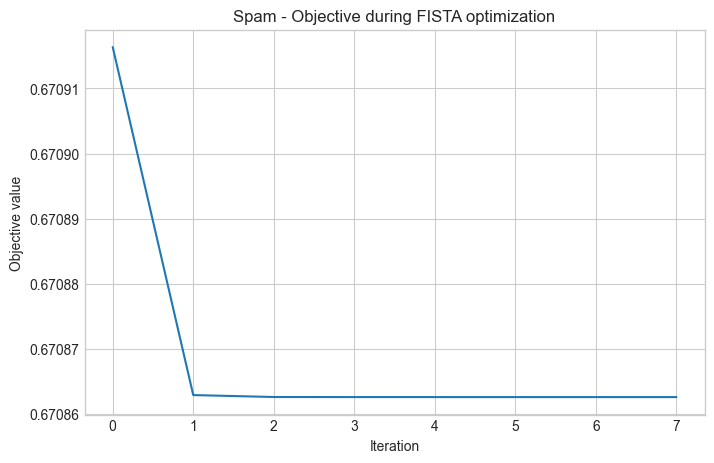

In [109]:
plt.figure(figsize=(8, 5))
plt.plot(model.objective_history_)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Spam - Objective during FISTA optimization")
plt.grid(True)
plt.show()

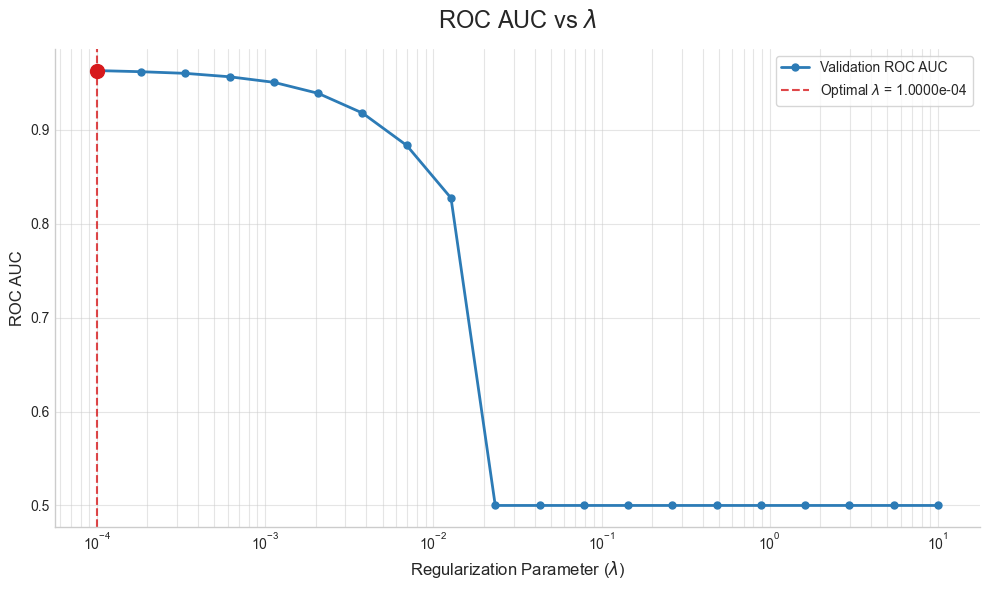

In [60]:
model.plot(X_valid=X_spam_test_scaled, y_valid=y_spam_test)

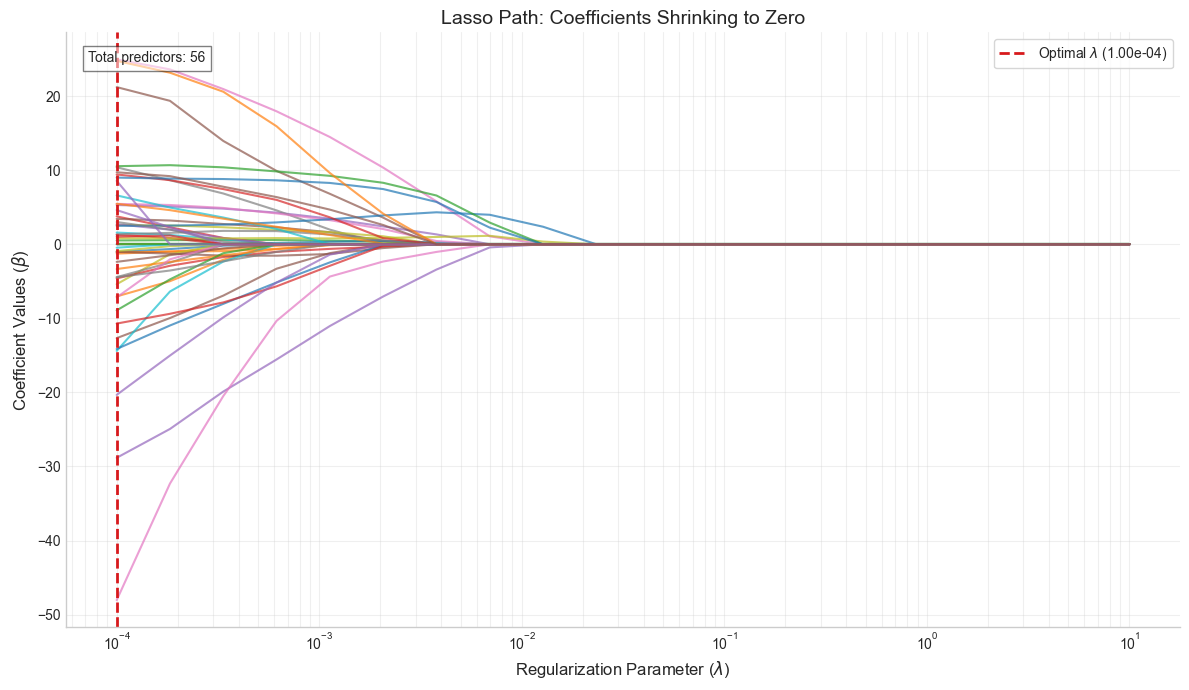

In [61]:
model.plot_coefficients()

## College

In [62]:
X_college = pd.read_csv(os.path.join(DATA_DIR, COLLEGE_DIR, "X.csv"))
y_college = pd.read_csv(os.path.join(DATA_DIR, COLLEGE_DIR, "Y.csv")).iloc[:, 0]

In [63]:
X_college.shape

(124699, 118)

In [64]:
X_college_train, X_college_test, y_college_train, y_college_test = train_test_split(
    X_college, 
    y_college,
    test_size=0.2,
    train_size=0.8, 
)

In [65]:
X_college_train_scaled = scaler.fit_transform(X_college_train)
X_college_test_scaled = scaler.transform(X_college_test)

In [67]:
model.fit(X_train=X_college_train_scaled, y_train=y_college_train)
model.validate(X_valid=X_college_test_scaled, y_valid=y_college_test)

0.9627179905767628

In [68]:
y_college_proba = model.predict_proba(X_test=X_college_test_scaled)
y_college_pred = (y_college_proba >= 0.5).astype(int)

In [70]:
print("Iterations:", model.n_iter_)
print("Intercept:", model.intercept_)
print("Number of zero coefficients:", np.sum(model.beta_ == 0.0))
print("Accuracy:", accuracy_score(y_college_test, y_college_pred))
print("ROC AUC:", roc_auc_score(y_college_test, y_college_proba))

Iterations: 116
Intercept: -9.343707536184468
Number of zero coefficients: 27
Accuracy: 0.936327185244587
ROC AUC: 0.9627179905767628


In [71]:
model.lambda_

0.0001

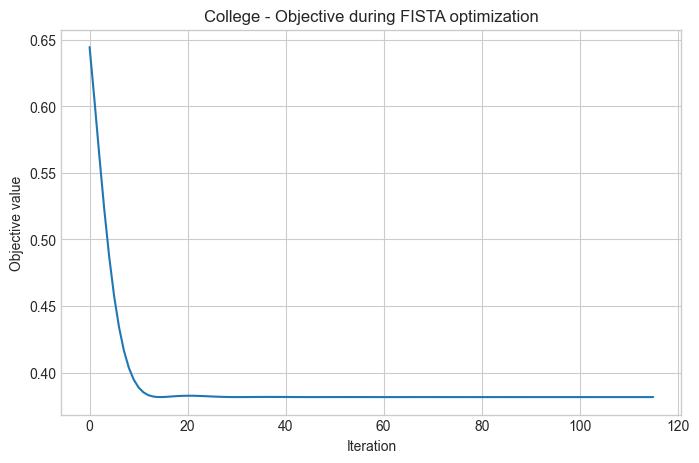

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(model.objective_history_)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("College - Objective during FISTA optimization")
plt.grid(True)
plt.show()

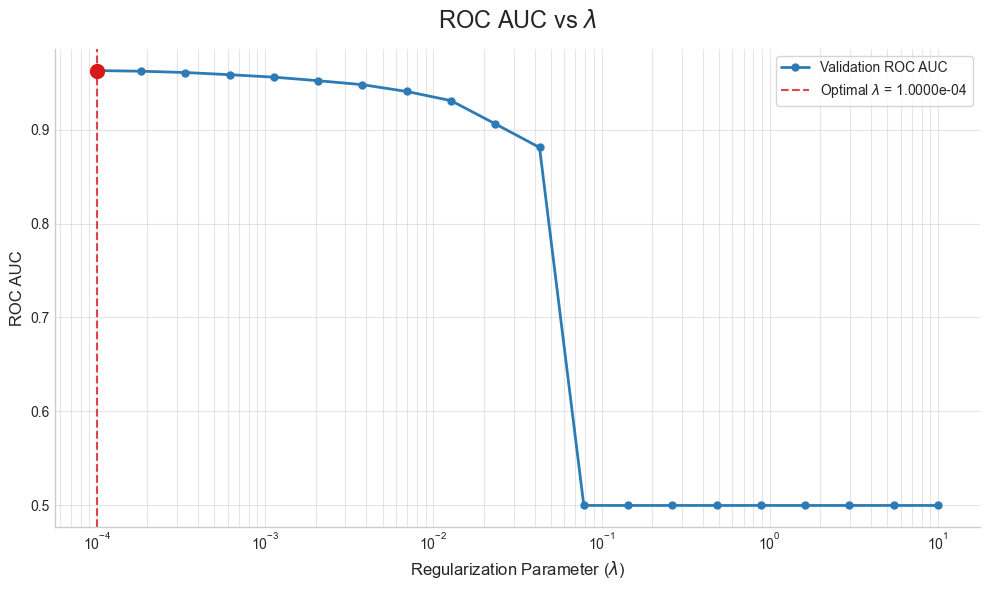

In [73]:
model.plot(X_valid=X_college_test_scaled, y_valid=y_college_test)

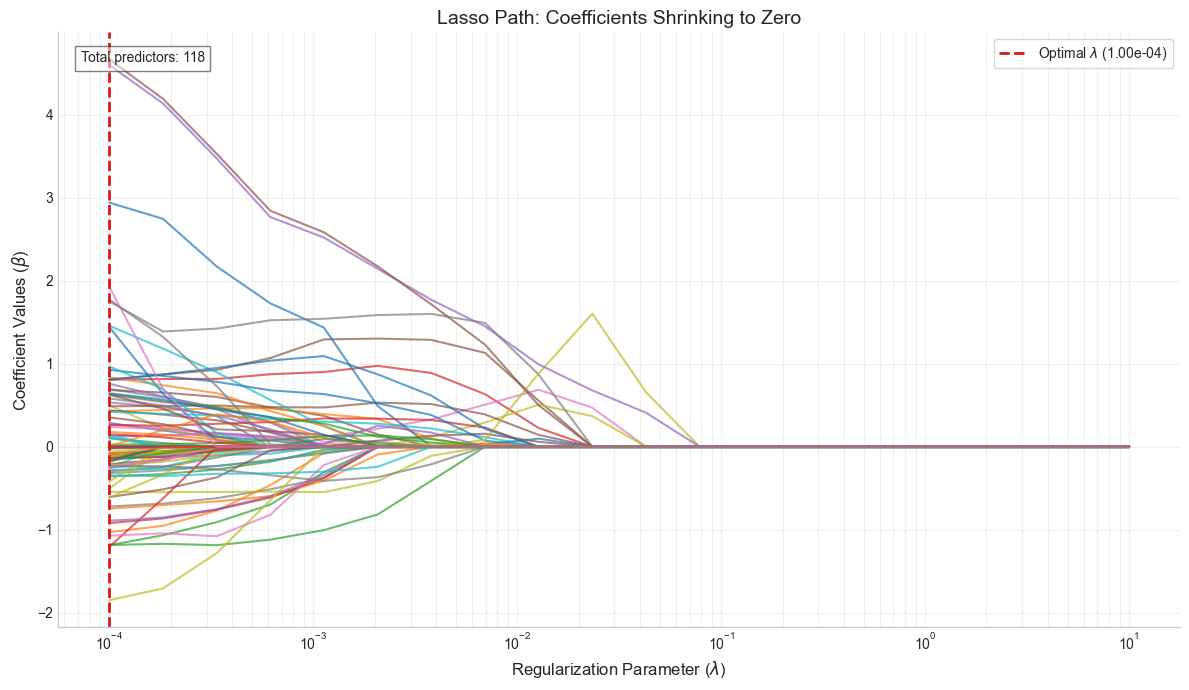

In [74]:
model.plot_coefficients()

## Electricity

In [77]:
X_electricity = pd.read_csv(os.path.join(DATA_DIR, ELECTRICITY_DIR, "X.csv"))
y_electricity = pd.read_csv(os.path.join(DATA_DIR, ELECTRICITY_DIR, "Y.csv")).iloc[:, 0]

In [78]:
X_electricity.shape

(45312, 8)

In [79]:
X_electricity_train, X_electricity_test, y_electricity_train, y_electricity_test = train_test_split(
    X_electricity, 
    y_electricity,
    test_size=0.2,
    train_size=0.8, 
)

In [80]:
X_electricity_train_scaled = scaler.fit_transform(X_electricity_train)
X_electricity_test_scaled = scaler.transform(X_electricity_test)

In [81]:
model.fit(X_train=X_electricity_train_scaled, y_train=y_electricity_train)
model.validate(X_valid=X_electricity_test_scaled, y_valid=y_electricity_test)

0.8225320785855619

In [82]:
y_electricity_proba = model.predict_proba(X_test=X_electricity_test_scaled)
y_electricity_pred = (y_electricity_proba >= 0.5).astype(int)

In [83]:
print("Iterations:", model.n_iter_)
print("Intercept:", model.intercept_)
print("Number of zero coefficients:", np.sum(model.beta_ == 0.0))
print("Accuracy:", accuracy_score(y_electricity_test, y_electricity_pred))
print("ROC AUC:", roc_auc_score(y_electricity_test, y_electricity_proba))

Iterations: 30
Intercept: -5.15056008294185
Number of zero coefficients: 1
Accuracy: 0.7568134171907757
ROC AUC: 0.8225320785855619


In [84]:
model.lambda_

0.0001

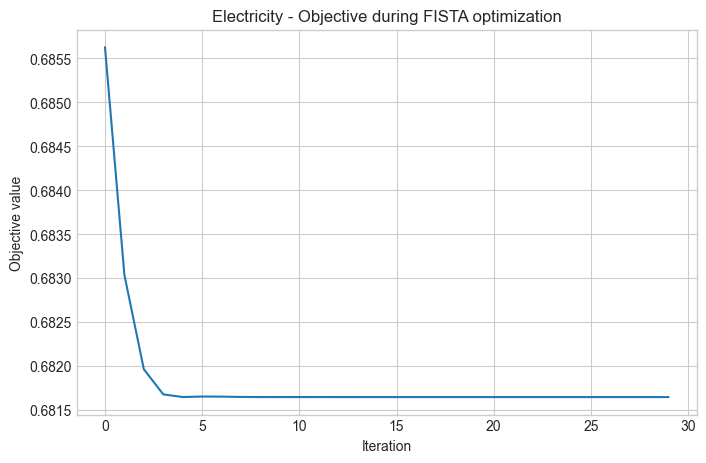

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(model.objective_history_)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Electricity - Objective during FISTA optimization")
plt.grid(True)
plt.show()

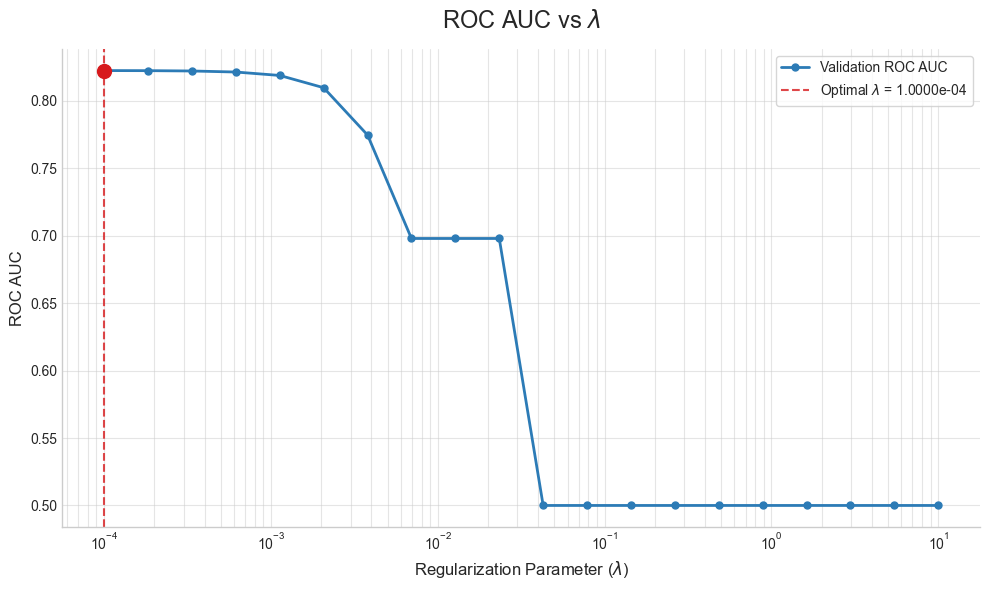

In [86]:
model.plot(X_valid=X_electricity_test_scaled, y_valid=y_electricity_test)

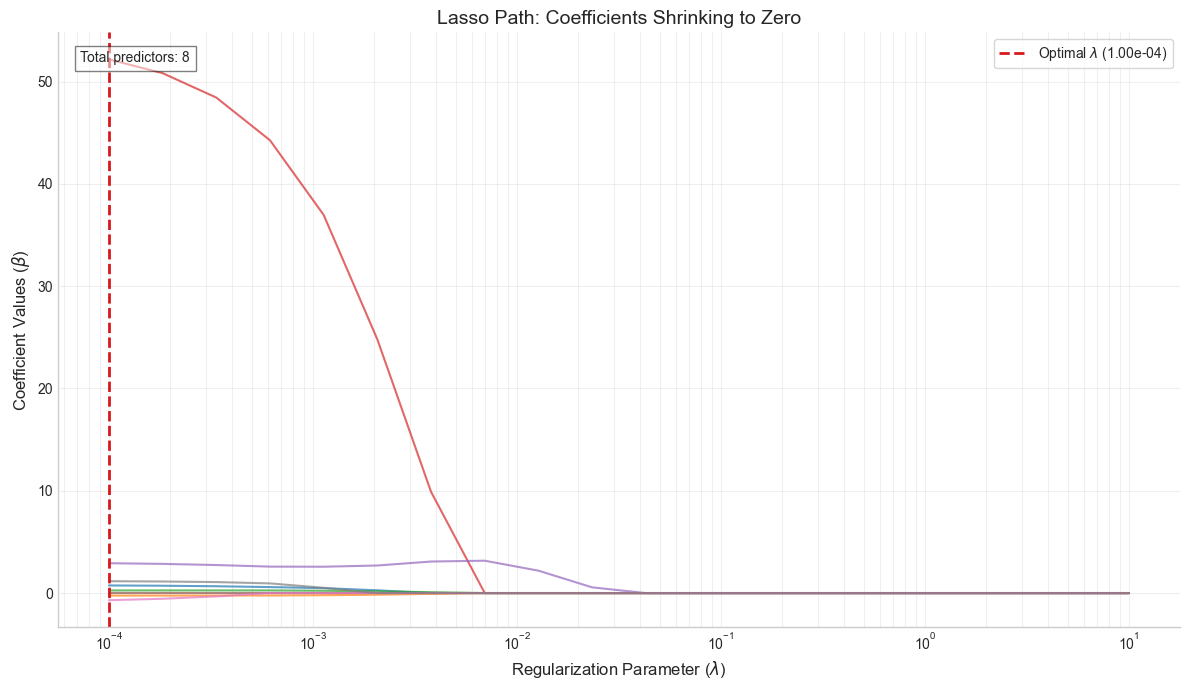

In [87]:
model.plot_coefficients()

## Employee

In [88]:
X_employee = pd.read_csv(os.path.join(DATA_DIR, EMPLOYEE_DIR, "X.csv"))
y_employee = pd.read_csv(os.path.join(DATA_DIR, EMPLOYEE_DIR, "Y.csv")).iloc[:, 0]

In [89]:
X_employee.shape

(34452, 9)

In [90]:
X_employee_train, X_employee_test, y_employee_train, y_employee_test = train_test_split(
    X_employee, 
    y_employee,
    test_size=0.2,
    train_size=0.8, 
)

In [91]:
X_employee_train_scaled = scaler.fit_transform(X_employee_train)
X_employee_test_scaled = scaler.transform(X_employee_test)

In [92]:
model.fit(X_train=X_employee_train_scaled, y_train=y_employee_train)
model.validate(X_valid=X_employee_test_scaled, y_valid=y_employee_test)

0.6933552259910337

In [93]:
y_employee_proba = model.predict_proba(X_test=X_employee_test_scaled)
y_employee_pred = (y_employee_proba >= 0.5).astype(int)

In [94]:
print("Iterations:", model.n_iter_)
print("Intercept:", model.intercept_)
print("Number of zero coefficients:", np.sum(model.beta_ == 0.0))
print("Accuracy:", accuracy_score(y_employee_test, y_employee_pred))
print("ROC AUC:", roc_auc_score(y_employee_test, y_employee_proba))

Iterations: 332
Intercept: 3.373138253199081
Number of zero coefficients: 2
Accuracy: 0.9870846031055
ROC AUC: 0.6933552259910337


In [95]:
model.lambda_

0.0001

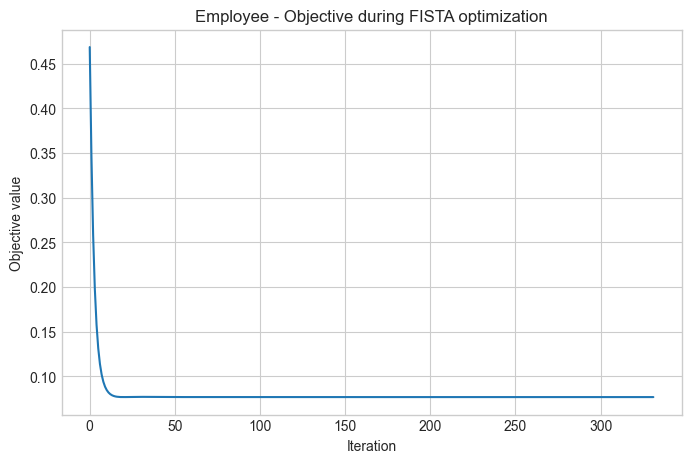

In [96]:
plt.figure(figsize=(8, 5))
plt.plot(model.objective_history_)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Employee - Objective during FISTA optimization")
plt.grid(True)
plt.show()

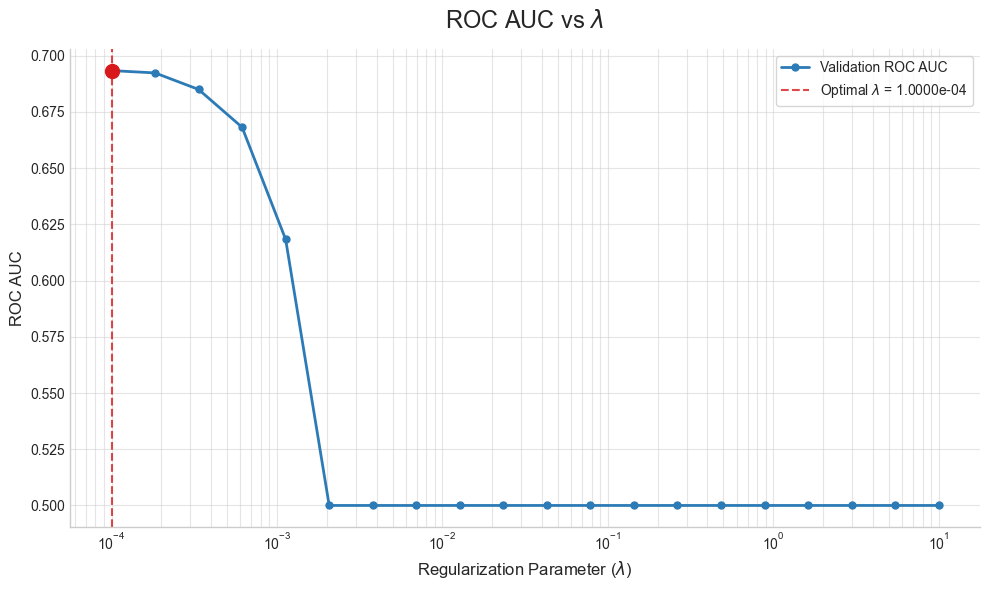

In [97]:
model.plot(X_valid=X_employee_test_scaled, y_valid=y_employee_test)

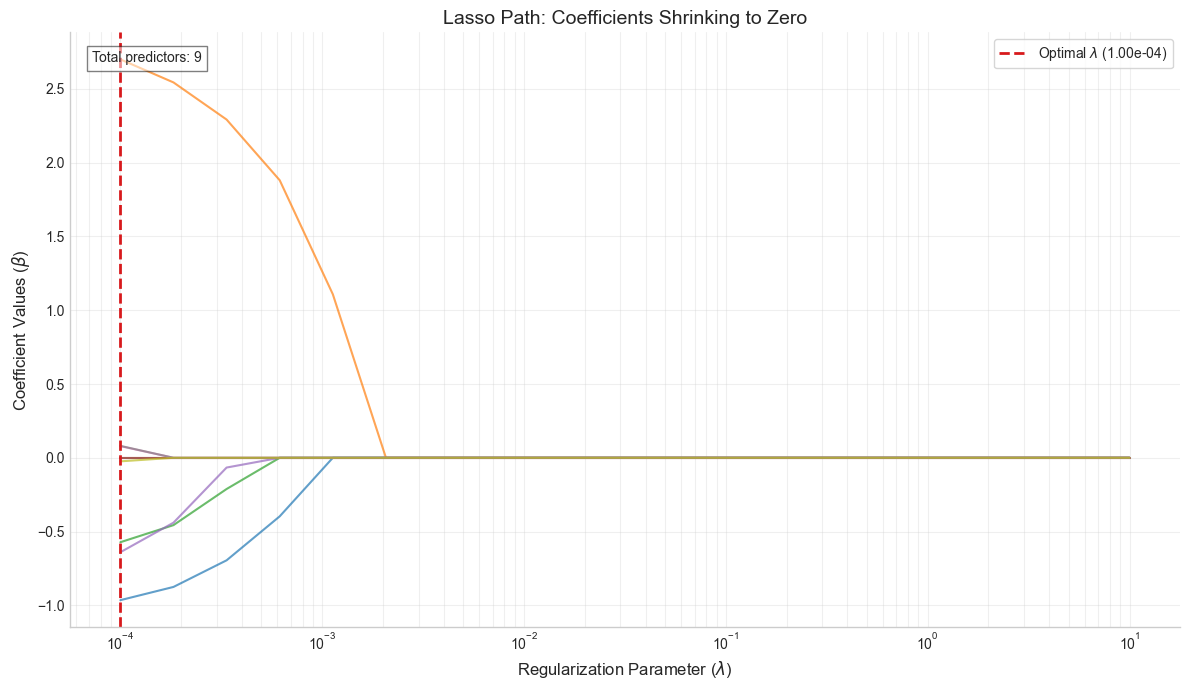

In [98]:
model.plot_coefficients()

## Comparison - our FISTA with sklearn

#### Spam

In [4]:
comparison_df_spam, metrics_df_spam, fista_model_spam, sklearn_model_spam = compare_fista_with_sklearn(
    X_train=X_spam_train,
    y_train=y_spam_train,
    X_test=X_spam_test,
    y_test=y_spam_test,
    lambdas=np.logspace(-4, 1, 20),
    dataframe="spam",
    measure="roc_auc",
    max_iter=5000,
    stop_condition=1e-6,
)

/Users/nadiaserafin/anaconda3/envs/aisd/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nadiaserafin/anaconda3/envs/aisd/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nadiaserafin/anaconda3/envs/aisd/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nadiaserafin/anaconda3/envs/aisd/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nadiaserafin/anaconda3/envs/aisd/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver

In [5]:
comparison_df_spam

,dataframe,measure_used_for_lambda_selection,fista_best_lambda,fista_best_score_on_test,fista_nonzero_coef,fista_intercept,sklearn_best_lambda_equiv,sklearn_best_C,sklearn_best_score_on_test,sklearn_nonzero_coef,sklearn_intercept,l2_distance_between_coefs,max_abs_difference_between_coefs
0,spam,roc_auc,0.0001,0.964253,50,-1.600671,0.023357,42.813324,0.96657,55,-1.539285,152.179312,114.53717


In [6]:
metrics_df_spam

,dataframe,model,recall,precision,f1,balanced_accuracy,roc_auc,avg_precision
0,spam,FISTA,0.885027,0.901907,0.893387,0.909607,0.964253,0.916431
1,spam,sklearn,0.903743,0.894180,0.898936,0.915309,0.966570,0.928583


#### College

In [12]:
comparison_df_college, metrics_df_college, fista_model_college, sklearn_model_college = compare_fista_with_sklearn(
    X_train=X_college_train,
    y_train=y_college_train,
    X_test=X_college_test,
    y_test=y_college_test,
    dataframe="college",
    lambdas=np.logspace(-4, 1, 20),
    measure="roc_auc",
    max_iter=5000,
    stop_condition=1e-6,
)

In [13]:
comparison_df_college

,dataframe,measure_used_for_lambda_selection,fista_best_lambda,fista_best_score_on_test,fista_nonzero_coef,fista_intercept,sklearn_best_lambda_equiv,sklearn_best_C,sklearn_best_score_on_test,sklearn_nonzero_coef,sklearn_intercept,l2_distance_between_coefs,max_abs_difference_between_coefs
0,college,roc_auc,0.0001,0.962647,87,-8.675475,0.042813,23.357215,0.963408,117,-9.304929,7.216771,3.175664


In [14]:
metrics_df_college

,dataframe,model,recall,precision,f1,balanced_accuracy,roc_auc,avg_precision
0,college,FISTA,0.666026,0.788316,0.722029,0.820226,0.962647,0.827659
1,college,sklearn,0.679808,0.792601,0.731884,0.827186,0.963408,0.830382


Electricity

In [17]:
comparison_df_electricity, metrics_df_electricity, fista_model_electricity, sklearn_model_electricity = compare_fista_with_sklearn(
    X_train=X_electricity_train,
    y_train=y_electricity_train,
    X_test=X_electricity_test,
    y_test=y_electricity_test,
    dataframe="electricity",
    lambdas=np.logspace(-4, 1, 20),
    measure="roc_auc",
    max_iter=5000,
    stop_condition=1e-6,
)

In [18]:
comparison_df_electricity

,dataframe,measure_used_for_lambda_selection,fista_best_lambda,fista_best_score_on_test,fista_nonzero_coef,fista_intercept,sklearn_best_lambda_equiv,sklearn_best_C,sklearn_best_score_on_test,sklearn_nonzero_coef,sklearn_intercept,l2_distance_between_coefs,max_abs_difference_between_coefs
0,electricity,roc_auc,0.0001,0.814591,7,-5.33758,0.003793,263.66509,0.815096,8,-5.455491,21.367636,21.146396


In [19]:
metrics_df_electricity

,dataframe,model,recall,precision,f1,balanced_accuracy,roc_auc,avg_precision
0,electricity,FISTA,0.605512,0.775723,0.680130,0.739268,0.814591,0.784584
1,electricity,sklearn,0.608399,0.772667,0.680764,0.739284,0.815096,0.784892


#### Employee

In [ ]:
comparison_df_employee, metrics_df_employee, fista_model_employee, sklearn_model_employee = compare_fista_with_sklearn(
    X_train=X_employee_train,
    y_train=y_employee_train,
    X_test=X_employee_test,
    y_test=y_employee_test,
    dataframe="employee",
    lambdas=np.logspace(-4, 1, 20),
    measure="roc_auc",
    max_iter=5000,
    stop_condition=1e-6,
)

In [23]:
comparison_df_employee

,dataframe,measure_used_for_lambda_selection,fista_best_lambda,fista_best_score_on_test,fista_nonzero_coef,fista_intercept,sklearn_best_lambda_equiv,sklearn_best_C,sklearn_best_score_on_test,sklearn_nonzero_coef,sklearn_intercept,l2_distance_between_coefs,max_abs_difference_between_coefs
0,employee,roc_auc,0.000183,0.686657,6,3.123912,5.455595,0.183298,0.686826,6,3.131727,0.070694,0.041301


In [24]:
metrics_df_employee

,dataframe,model,recall,precision,f1,balanced_accuracy,roc_auc,avg_precision
0,employee,FISTA,1.0,0.985924,0.992912,0.5,0.686657,0.992724
1,employee,sklearn,1.0,0.985924,0.992912,0.5,0.686826,0.992744


#### All together

In [25]:
comparison_df = pd.concat([
    comparison_df_spam,
    comparison_df_college,
    comparison_df_electricity,
    comparison_df_employee,
])

In [26]:
comparison_df

,dataframe,measure_used_for_lambda_selection,fista_best_lambda,fista_best_score_on_test,fista_nonzero_coef,fista_intercept,sklearn_best_lambda_equiv,sklearn_best_C,sklearn_best_score_on_test,sklearn_nonzero_coef,sklearn_intercept,l2_distance_between_coefs,max_abs_difference_between_coefs
0,spam,roc_auc,0.000100,0.964253,50,-1.600671,0.023357,42.813324,0.966570,55,-1.539285,152.179312,114.537170
0,college,roc_auc,0.000100,0.962647,87,-8.675475,0.042813,23.357215,0.963408,117,-9.304929,7.216771,3.175664
0,electricity,roc_auc,0.000100,0.814591,7,-5.337580,0.003793,263.665090,0.815096,8,-5.455491,21.367636,21.146396
0,employee,roc_auc,0.000183,0.686657,6,3.123912,5.455595,0.183298,0.686826,6,3.131727,0.070694,0.041301


In [ ]:
metrics_df = pd.concat([
    metrics_df_spam,
    metrics_df_college,
    metrics_df_electricity,
    metrics_df_employee,
])

In [28]:
metrics_df

,dataframe,model,recall,precision,f1,balanced_accuracy,roc_auc,avg_precision
0,spam,FISTA,0.885027,0.901907,0.893387,0.909607,0.964253,0.916431
1,spam,sklearn,0.903743,0.894180,0.898936,0.915309,0.966570,0.928583
0,college,FISTA,0.666026,0.788316,0.722029,0.820226,0.962647,0.827659
1,college,sklearn,0.679808,0.792601,0.731884,0.827186,0.963408,0.830382
0,electricity,FISTA,0.605512,0.775723,0.680130,0.739268,0.814591,0.784584
1,electricity,sklearn,0.608399,0.772667,0.680764,0.739284,0.815096,0.784892
0,employee,FISTA,1.000000,0.985924,0.992912,0.500000,0.686657,0.992724
1,employee,sklearn,1.000000,0.985924,0.992912,0.500000,0.686826,0.992744
